In [3]:
import sympy as sp
import numpy as np
sp.init_printing()
S,I,R = sp.symbols('S I R')
t0, beta1, gamma, f, sigma = sp.symbols('t0 beta1 gamma f sigma')
first_term_numerator = sp.Matrix([-beta1*S*I,beta1*S*I-gamma*I,gamma*I])
first_term_denominator = sp.Matrix([t0, beta1, gamma, f, sigma])
second_term_denominator = sp.Matrix([S,I,R])
aa = first_term_numerator.jacobian(first_term_denominator)
bb = first_term_numerator.jacobian(second_term_denominator)
n,m = 3,5
s = sp.MatrixSymbol('s',n*m,1)
ds = sp.MatrixSymbol('ds',n,m)
v1 = sp.MutableDenseNDimArray.zeros(n,m,n)
for i in range(n):
    for j in range(m):
        for l in range(n):
            v1[i,j,l] = bb[i,l]*s[m*l+j]        
v2 = np.sum(v1,-1)
ds = aa + v2
F2 = sp.zeros(18,1)
F2[:n,0] = first_term_numerator[:]
F2[n:,0] = ds.reshape(n*m,1)
x2 = sp.Matrix([S,I,R,s])
jointJ1 = F2.jacobian(x2)

In [8]:
jointJ2 = sp.zeros(n*(m+1),n*(m+1))
jointJ2[:n,:n] = bb
jointJ2[n:,:n] = sp.Matrix([[0, 0, 0], [-I, -S, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [I, S, 0], [0, -1, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 1, 0], [0, 0, 0], [0, 0, 0]])
jointJ2[n:,n:] = np.tensordot(bb, np.eye(m), axes=0).swapaxes(1, 2).reshape((n*m,n*m))

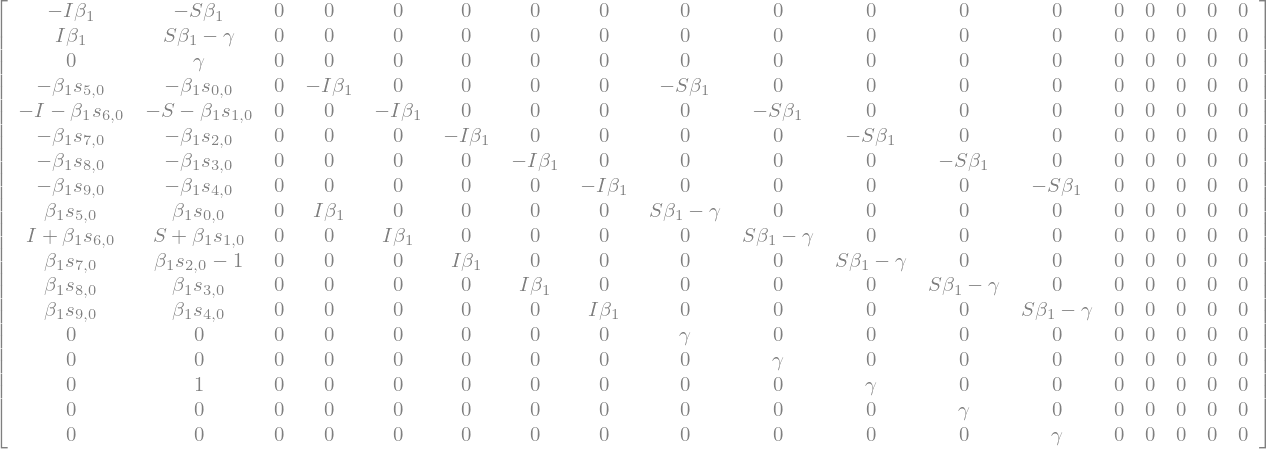

In [20]:
jointJ1

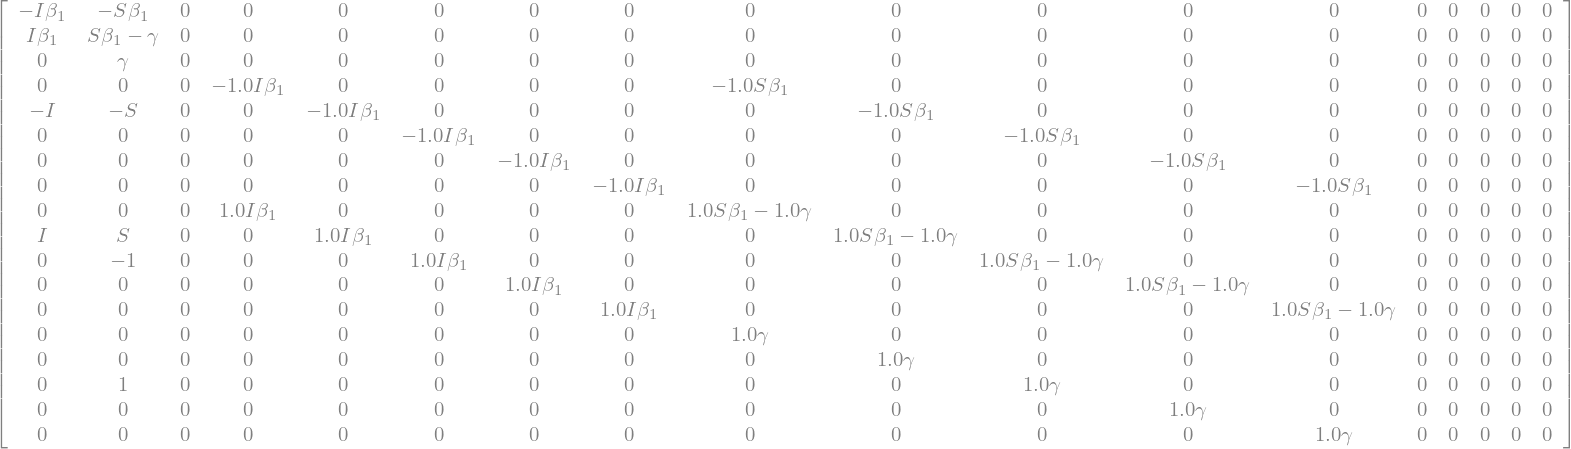

In [21]:
jointJ2